<a href="https://colab.research.google.com/github/mattu117117/For-classroom/blob/main/Lecture3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 下記セルを実行すると、authorization codeの入力を求められます。
# 出力されたリンク先をクリックし、Googleアカウントにログインし、
# authorization codeをコピーし、貼り付けをおこなってください。
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
project = '25SA_Ex'
chapter = 3
os.chdir(f'/content/drive/MyDrive/25StatisticalAnalysisEx./Lecture3')   # ←自分の環境に合うように適宜修正してください。

# 第３回 時系列データの加工・可視化

## ノック４１：時系列データを読み込んでみよう
まず、glob というライブラリを使って指定したパターンにマッチするかたまり（ファイルのパス）の一覧（リスト）を取得します。そしてのそのファイルパスのリストを files という変数に格納します。「*」はワイルドカードといって任意の文字列が入ります。1文字ではなく文字列です。

"*" を使ってワイルドカード示すのは、Linux をはじめ多くのシステムで利用されている流儀です。len(files) でリストの長さを見ることができます。

files[:5]は、「files のうち初めから5つ目まで」を指します。files[20:]とすれば、「20行目から最後まで」、files[:] とすれば「全部の行」という意味です。

":" を使って「最後まで」とか「最初から」とか「全部」とかを示す方法は Matlab などでもつかわれている流儀です。

In [5]:
from glob import glob
files = glob('data/person_count_1sec/out_0001/*.csv')
files.sort()
display(files[:5])
len(files)

['data/person_count_1sec/out_0001/person_count_out_0001_2021011509.csv',
 'data/person_count_1sec/out_0001/person_count_out_0001_2021011510.csv',
 'data/person_count_1sec/out_0001/person_count_out_0001_2021011511.csv',
 'data/person_count_1sec/out_0001/person_count_out_0001_2021011512.csv',
 'data/person_count_1sec/out_0001/person_count_out_0001_2021011513.csv']

729

では、ファイルを1つだけ読み込んで、先頭の5行の表示、データタイプの確認をします。

In [6]:
import pandas as pd
data = pd.read_csv(files[0])
display(data.head(5))
print(data.dtypes)

,id,place,receive_time,sensor_num,in1,out1,state1,in2,out2,state2
0,0,1,2021-01-15 09:00:00.144,2,508,73,0,73,508,0
1,1,1,2021-01-15 09:00:01.146,2,508,73,0,73,508,0
2,2,1,2021-01-15 09:00:02.161,2,508,73,0,73,508,0
3,3,1,2021-01-15 09:00:03.176,2,508,73,0,73,508,0
4,4,1,2021-01-15 09:00:04.192,2,508,73,0,73,508,0


id               int64
place            int64
receive_time    object
sensor_num       int64
in1              int64
out1             int64
state1           int64
in2              int64
out2             int64
state2           int64
dtype: object


receive_time を見てみると、ms （ミリ秒）まで記録されていることが分かります。IoTなどのセンサデータではミリ秒単位まで記録されていることが多いです。receive_time の型は object となっており、このままでは文字列としてしか使えないので、datetime に変換します。

In [7]:
data['receive_time'] = pd.to_datetime(data['receive_time'],errors='coerce')    #format='%Y-%m-%d',errors='coerce'
display(data.head())
print(data.dtypes)

,id,place,receive_time,sensor_num,in1,out1,state1,in2,out2,state2
0,0,1,2021-01-15 09:00:00.144,2,508,73,0,73,508,0
1,1,1,2021-01-15 09:00:01.146,2,508,73,0,73,508,0
2,2,1,2021-01-15 09:00:02.161,2,508,73,0,73,508,0
3,3,1,2021-01-15 09:00:03.176,2,508,73,0,73,508,0
4,4,1,2021-01-15 09:00:04.192,2,508,73,0,73,508,0


id                       int64
place                    int64
receive_time    datetime64[ns]
sensor_num               int64
in1                      int64
out1                     int64
state1                   int64
in2                      int64
out2                     int64
state2                   int64
dtype: object


datetime 型に変換しても見た目は全くかわりませんが、型をみると datetime64[ns] ときちんと変わっていることが確認できます。

次は、glob で取得したファイルパスを for文で順番に読み込み、必要な変換をして、1つのデータフレームを作ります。append しただけだと、データシートがリストの形で格納されていて使いにくいので、concat を使って、大きな1つのデータシートへと統合します。len(data)でデータ件数を調べます。

ファイル数がそこそこあるので、そこそこ時間がかかります。6分かかる時もありました。

In [8]:
data = []
for f in files:
  # tmp = pd.read_csv(f, parse_dates=["receive_time"]) # 読み込みつつ変換できれば高効率だが、何故かうまくいかない。しかたがないので以下の2行で処理します。
  tmp = pd.read_csv(f)
  tmp['receive_time'] = pd.to_datetime(tmp['receive_time'],errors='coerce')
  data.append(tmp)
data = pd.concat(data,ignore_index=True)
display(data.head())
len(data)

,id,place,receive_time,sensor_num,in1,out1,state1,in2,out2,state2
0,0,1,2021-01-15 09:00:00.144,2,508,73,0,73,508,0
1,1,1,2021-01-15 09:00:01.146,2,508,73,0,73,508,0
2,2,1,2021-01-15 09:00:02.161,2,508,73,0,73,508,0
3,3,1,2021-01-15 09:00:03.176,2,508,73,0,73,508,0
4,4,1,2021-01-15 09:00:04.192,2,508,73,0,73,508,0


2346162

## ノック４２：日付の範囲を確認しよう
データシートの準備ができたら、分析対象の範囲を調べておきましょう。receive_time を datetime 型に変換済みですので、max()、min()などの関数を使えます。

さらに、max()-min()をすれば、計測期間を出力することもできます。

In [9]:
min_receive_time = data['receive_time'].min()
max_receive_time = data['receive_time'].max()
print(min_receive_time)
print(max_receive_time)

print(data['receive_time'].max()-data['receive_time'].min())

2021-01-15 09:00:00.144000
2021-02-14 17:59:59.956000
30 days 08:59:59.812000


## ノック４３：日毎のデータ件数を確認しよう
次に、日毎のデータ件数を確認しましょう。データ件数を把握しておくことは重要です。センサデータのような場合、仕様的には１秒ごとにデータを取得している場合でも、センサの故障や、記録媒体への書き込みの失敗、などの原因でデータが欠損してしまうことはよくあります。

そこで、日単位でデータ件数を把握します。receive_time はミリ秒単位ですので、これを日単位のデータにした後、集計すれば良さそうです。dt.date で日付までのデータに変換できます。dt.year や dt.hour で年や時間などを取得することもできます。

集計には、groupby が使えますね。

In [10]:
data['receive_date'] = data['receive_time'].dt.date
# display(data.head())

daily_count = data[['receive_date','id']].groupby('receive_date', as_index=False).count()
daily_count.head()

,receive_date,id
0,2021-01-15,50118
1,2021-01-16,75614
2,2021-01-17,73123
3,2021-01-18,75401
4,2021-01-19,78270


2021年1月15日は、データ件数が少ないですが、これは開始時間が9時からであるためです。16日以降のデータは24時間記録しているので、24x60x60=8,640 件 あるはずですが、約10,000件も想定よりは少ないようです。

それでは30日分を棒グラフで見てみましょう。

<Axes: xlabel='receive_date', ylabel='id'>

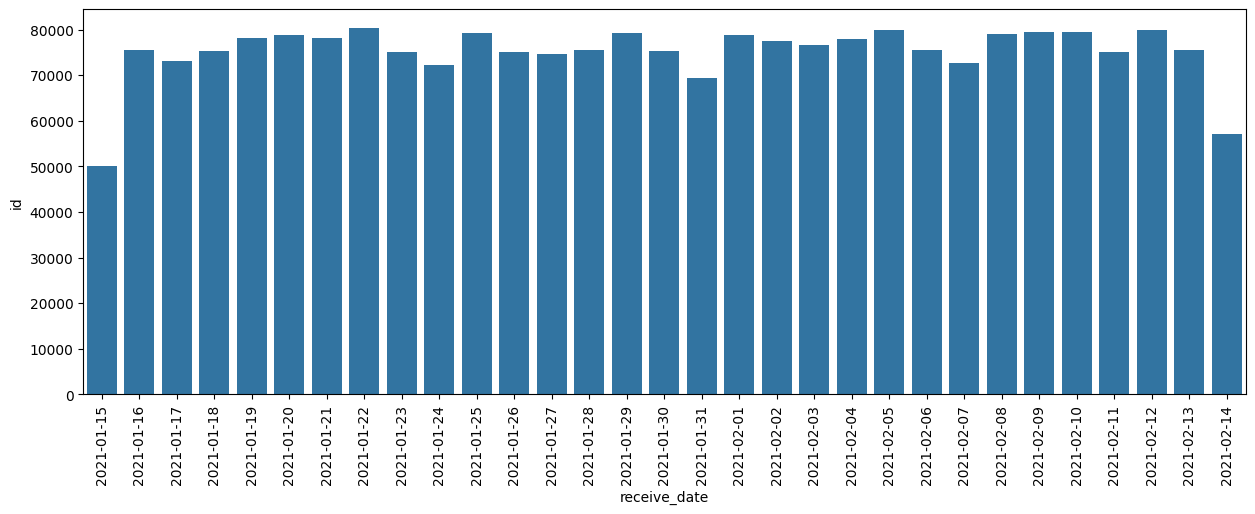

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.xticks(rotation=90)
sns.barplot(x=daily_count['receive_date'], y=daily_count["id"])

データ数は1日あたり約70,000件のようです。よくみると、23日、24日や30日、31日のところはさらにデータ件数が少ないようです。5日間7万件ぐらいで、2日間それより下がる、、、、という規則性から曜日が関係していることが想像できますね。次のノックで曜日を確認してみましょう。

## ノック４４：日付から曜日を算出しよう
曜日の取得は"数字"でとる場合と"英語名"でとる場合があります。

In [12]:
data['dayofweek'] = data['receive_time'].dt.dayofweek
data['day_name'] = data['receive_time'].dt.day_name()
data.head()

,id,place,receive_time,sensor_num,in1,out1,state1,in2,out2,state2,receive_date,dayofweek,day_name
0,0,1,2021-01-15 09:00:00.144,2,508,73,0,73,508,0,2021-01-15,4.0,Friday
1,1,1,2021-01-15 09:00:01.146,2,508,73,0,73,508,0,2021-01-15,4.0,Friday
2,2,1,2021-01-15 09:00:02.161,2,508,73,0,73,508,0,2021-01-15,4.0,Friday
3,3,1,2021-01-15 09:00:03.176,2,508,73,0,73,508,0,2021-01-15,4.0,Friday
4,4,1,2021-01-15 09:00:04.192,2,508,73,0,73,508,0,2021-01-15,4.0,Friday


なんと dt.dayofweek や dt.day_name() などで曜日は簡単にとれるんですね。数字でとるか英語名でとるかはケースバイケースですが、数字の方がデータは軽いです。一方で数字だけだと何番がどの曜日なのかがわかりにくいので、可視化の際は英語名での取得や、番号を取得してそれに対応した日本語名を代入するのが良いです。

0番が月曜日で、、、6番が日曜日です。dayofweek と day_name を並べて出力して番号と曜日の対応を確認してみましょう。この場合、1つの日付について1つのデータが出力されればよいので、 drop_duplicates() で () の内の引数ごとにユニークになるように重複しているデータ行を削除します。先頭を12行だしてみます。



In [13]:
data[['receive_date','dayofweek','day_name']].drop_duplicates(subset='receive_date').head(12)

,receive_date,dayofweek,day_name
0,2021-01-15,4.0,Friday
404,NaT,NaN,NaN
50166,2021-01-16,5.0,Saturday
125865,2021-01-17,6.0,Sunday
199063,2021-01-18,0.0,Monday
277428,2021-01-19,1.0,Tuesday
355776,2021-01-20,2.0,Wednesday
434668,2021-01-21,3.0,Thursday
513010,2021-01-22,4.0,Friday
593585,2021-01-23,5.0,Saturday


出力結果を見ると、先ほどのデータ件数の確認で、23日、24日のデータが少なかったのですが、これは土曜日、日曜日であることが分かりました。

表をよく見てみると、 NaT、NaN、NaN と表示された行が出てしまうことがあります。これは、receive_date のところで何らかの理由で to_datetime() の変換に失敗してしまっているためです。（原因はもとの csv ファイルで確認できるはずですが高橋は未確認です。調査していないです。）変換の失敗のために、NaT が記録され、またこれは datetime 型でないので、at.dayofweek や at.day_name() の変換もできず、NaN が記録されています。

ただ、今回の「曜日と番号の対応を確認する」という目的の邪魔なしないので、この問題はこのまま放置します。

## ノック４５：特定範囲のデータに絞り込もう
それではデータの詳細を見ていくにあたり、すべての日を扱うのは大変なので、ある特定の範囲に絞り込んでみていくことにします。ひとまず1月20日、21日、22日のデータに絞り込んでみましょう。

年月日を表現するには、Python の標準ライブラリである datetime を使うと便利です。import して使っていきます。使い方としては、datetime(2024.10.17) で2024年10月17日を表します。

データの絞り込みには loc を使いますが、これの条件として、不等式を使うことができます。やってみましょう。

In [14]:
import datetime as dt
data_extract = data.loc[(data['receive_time']>=dt.datetime(2021,1,20))&
                        (data['receive_time']<dt.datetime(2021,1,23))].copy()
display(data_extract.head())
display(data_extract.tail())

,id,place,receive_time,sensor_num,in1,out1,state1,in2,out2,state2,receive_date,dayofweek,day_name
355776,0,1,2021-01-20 00:00:40.839,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday
355777,1,1,2021-01-20 00:00:41.854,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday
355778,2,1,2021-01-20 00:00:56.055,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday
355779,3,1,2021-01-20 00:00:57.071,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday
355780,4,1,2021-01-20 00:00:58.086,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday


,id,place,receive_time,sensor_num,in1,out1,state1,in2,out2,state2,receive_date,dayofweek,day_name
593580,2620,1,2021-01-22 23:58:32.865,2,21150,19675,0,19701,21107,0,2021-01-22,4.0,Friday
593581,2621,1,2021-01-22 23:58:33.881,2,21150,19675,0,19701,21107,0,2021-01-22,4.0,Friday
593582,2622,1,2021-01-22 23:58:34.896,2,21150,19675,0,19701,21107,0,2021-01-22,4.0,Friday
593583,2623,1,2021-01-22 23:58:35.912,2,21150,19675,0,19701,21107,0,2021-01-22,4.0,Friday
593584,2624,1,2021-01-22 23:58:36.927,2,21150,19675,0,19701,21107,0,2021-01-22,4.0,Friday


## ノック４６：秒単位のデータを作成しよう
今回は1秒ごとに計測しているので、〇月〇日〇時〇分〇秒まででよいのですが、今回のデータ自体には、00:00:40.839、00:00:401.854 などのようにミリ秒単位までされています。秒単位にまるめていきましょう。ミリ秒単位を秒単位にする場合は、round を使います。round('S')の'S'は second の S です。round は四捨五入です。どの頻度でまるめるかは細かく指定できて、例えば10秒間隔であれば、 round('10S') などと指定することで、10秒単位でまるめることができます。

In [15]:
data_extract['receive_time_sec'] = data_extract['receive_time'].dt.round('S')
data_extract.head()

/tmp/ipython-input-3810909111.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  data_extract['receive_time_sec'] = data_extract['receive_time'].dt.round('S')


,id,place,receive_time,sensor_num,in1,out1,state1,in2,out2,state2,receive_date,dayofweek,day_name,receive_time_sec
355776,0,1,2021-01-20 00:00:40.839,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday,2021-01-20 00:00:41
355777,1,1,2021-01-20 00:00:41.854,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday,2021-01-20 00:00:42
355778,2,1,2021-01-20 00:00:56.055,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday,2021-01-20 00:00:56
355779,3,1,2021-01-20 00:00:57.071,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday,2021-01-20 00:00:57
355780,4,1,2021-01-20 00:00:58.086,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday,2021-01-20 00:00:58


秒単位に丸めた際に、必ず重複がないかを確認しておきましょう。取得時間が完璧に同じでセンサであれば、00:00:40.839、00:00:41.839、00:00:42.839 と正確に1.000づつデータが増えていきますが、そういったことはほとんどなく今回のデータのようにミリ秒多淫位のずれはでてきます。重複のあるなしは、全データ数と .unique() を使ったユニークデータ数とを比較することで分かります。

In [16]:
print(len(data_extract))
print(len(data_extract['receive_time_sec'].unique()))

237513
237511


2件だけずれてしまったようです。では、重複データを確認してみましょう。

In [17]:
data_extract[data_extract['receive_time_sec'].duplicated(keep=False)].head()

,id,place,receive_time,sensor_num,in1,out1,state1,in2,out2,state2,receive_date,dayofweek,day_name,receive_time_sec
578874,887,1,2021-01-22 19:15:06.530,2,20968,18976,1,19002,20925,1,2021-01-22,4.0,Friday,2021-01-22 19:15:07
578875,888,1,2021-01-22 19:15:07.409,2,20968,18976,1,19002,20925,1,2021-01-22,4.0,Friday,2021-01-22 19:15:07
578876,889,1,2021-01-22 19:15:07.546,2,20968,18976,1,19002,20925,1,2021-01-22,4.0,Friday,2021-01-22 19:15:08
578877,890,1,2021-01-22 19:15:08.424,2,20968,18976,1,19002,20925,1,2021-01-22,4.0,Friday,2021-01-22 19:15:08


duplicated で重複しているかの True/False を取得します。その際に、keepに False を指定することで重複しているデータの両方を False にすることができます。

データ見てみると、19:15:06.530 は 19:15:07 に、19:15:07.409 も 19:15:07 となり重複してしまうことが確認できます。これは四捨五入していることに起因します。

それでは、floor を使った切り捨てもやってみましょう。合わせて重複件数の確認と重複データの確認もします。

In [18]:
data_extract['receive_time_sec'] = data_extract['receive_time'].dt.floor('S')
display(data_extract.head())
print(len(data_extract))
print(len(data_extract['receive_time_sec'].unique()))

data_extract[data_extract['receive_time_sec'].duplicated(keep=False)].head()

/tmp/ipython-input-3717663551.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  data_extract['receive_time_sec'] = data_extract['receive_time'].dt.floor('S')


,id,place,receive_time,sensor_num,in1,out1,state1,in2,out2,state2,receive_date,dayofweek,day_name,receive_time_sec
355776,0,1,2021-01-20 00:00:40.839,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday,2021-01-20 00:00:40
355777,1,1,2021-01-20 00:00:41.854,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday,2021-01-20 00:00:41
355778,2,1,2021-01-20 00:00:56.055,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday,2021-01-20 00:00:56
355779,3,1,2021-01-20 00:00:57.071,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday,2021-01-20 00:00:57
355780,4,1,2021-01-20 00:00:58.086,2,12109,11302,0,11318,12080,0,2021-01-20,2.0,Wednesday,2021-01-20 00:00:58


237513
237512


,id,place,receive_time,sensor_num,in1,out1,state1,in2,out2,state2,receive_date,dayofweek,day_name,receive_time_sec
578875,888,1,2021-01-22 19:15:07.409,2,20968,18976,1,19002,20925,1,2021-01-22,4.0,Friday,2021-01-22 19:15:07
578876,889,1,2021-01-22 19:15:07.546,2,20968,18976,1,19002,20925,1,2021-01-22,4.0,Friday,2021-01-22 19:15:07


構文は round のときとほぼ同じですね。データを確認すると 00:00:40.839 が 00:00:40 となっており round の時と違うのが確認できますね。

重複データは1件だけです。データ見てみると、19:15:07.409 と 19:15:07.546 が重複を起こしてしまっています。センサ設定時には 1秒(1000ms)ごとに計測と設定していても、実際にはここのところだけ、およそ 100ms 後に次の測定をしてしまっていることが原因ですね。本来、秒単位のデータなのに、実際によくみてみるとこのようになってしまうこことは意外とよくあります。（安いセンサ、安いデバイスほど起こり易い。）

四捨五入にするのか、切り捨てにするのかは議論が分かれるところですが、今回のケースのようにセンサデータが大量に存在する場合はあまり大きな問題ではないです。全体の件数のインパクトとしても、237809件のうち1件もしくは2件レベルの重複でした。

今回はこのまま floor で切り捨てたデータで重複削除をして進むことにします。合わせて、開始から終了までの日付を取得しておきます。

In [19]:
data_extract = data_extract.drop_duplicates(subset=['receive_time_sec'])
min_receive_time = data_extract['receive_time_sec'].min()
max_receive_time = data_extract['receive_time_sec'].max()
print(len(data_extract))
print(f'{min_receive_time}から{max_receive_time}')

237512
2021-01-20 00:00:40から2021-01-22 23:58:36


drop_duplicates で重複データの削除をしています。その際に、receive_time_sec データの重複だけ削除するために、subset で receive_time_sec を指定しています。データの件数は 237808 となり、1件の重複が削除されました。

## ノック４７：秒単位のデータを整形しよう
ノック43のところで一度触れていますが、重複だけでなくデータの”抜け”についてもチェックしておかなければなりません。センサデータは決められた時間間隔で取得しているはずですが、データの抜けは結構あるものです。

ノック46の floor で切り捨てた後に出力された表を見てください。

00:00:40.839 と 00:00:41.854 の間はほぼ1秒間かですが、その後に 00:00:56.055	となっておりデータが飛んでいます。機械学習等でデータを利用する際に、1秒間隔でデータがきているということを前提として時系列情報を保持してモデル構築する場合もあり、今回のようなデータでは不都合をきたします。そこで、ここでは綺麗に秒単位のデータになるように整形していきます。

今回の方法としては、1秒間隔の日付データをあらかじめ作成し、そこに今回のデータを結合してみます。

まずは、pd_date_range() を使って1秒間隔の日付データを作ります。引数で、開始日、終了日、データ作成頻度 freq を指定します。freq=('S') で1秒間隔でとなります。freq=('10S') とすれば10秒間隔にもできます。ちょっと練習してみましょう。



In [20]:
print(pd.date_range('2021-01-15', '2021-01-16', freq='S'))


DatetimeIndex(['2021-01-15 00:00:00', '2021-01-15 00:00:01',
               '2021-01-15 00:00:02', '2021-01-15 00:00:03',
               '2021-01-15 00:00:04', '2021-01-15 00:00:05',
               '2021-01-15 00:00:06', '2021-01-15 00:00:07',
               '2021-01-15 00:00:08', '2021-01-15 00:00:09',
               ...
               '2021-01-15 23:59:51', '2021-01-15 23:59:52',
               '2021-01-15 23:59:53', '2021-01-15 23:59:54',
               '2021-01-15 23:59:55', '2021-01-15 23:59:56',
               '2021-01-15 23:59:57', '2021-01-15 23:59:58',
               '2021-01-15 23:59:59', '2021-01-16 00:00:00'],
              dtype='datetime64[ns]', length=86401, freq='s')


/tmp/ipython-input-1523658341.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  print(pd.date_range('2021-01-15', '2021-01-16', freq='S'))


では、対象とする特定範囲のデータ期間（20日～22日）で1秒間隔データを作ってみます。

In [21]:
base_data = pd.DataFrame({'receive_time_sec':pd.date_range(min_receive_time, max_receive_time,freq='S')})
display(base_data.head())
display(base_data.tail())
print(len(base_data))

/tmp/ipython-input-319793831.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  base_data = pd.DataFrame({'receive_time_sec':pd.date_range(min_receive_time, max_receive_time,freq='S')})


,receive_time_sec
0,2021-01-20 00:00:40
1,2021-01-20 00:00:41
2,2021-01-20 00:00:42
3,2021-01-20 00:00:43
4,2021-01-20 00:00:44


,receive_time_sec
259072,2021-01-22 23:58:32
259073,2021-01-22 23:58:33
259074,2021-01-22 23:58:34
259075,2021-01-22 23:58:35
259076,2021-01-22 23:58:36


259077


作成した base_data は 259077件となりました。センサデータ（20日～22日）が 237512 なので、センサデータ（20日～22日）には 21565件の欠損があることがわかりました。

それでは、作成した base_data と センサデータ data_extract を merge() を使って結合します。第1引数と第2引数にそれぞれのデータフレームを指定します。

on=でキー列を指定します。指定がなければ共通する列名の列で結合処理されますが、解読性のためには明示しておいた方がいいでしょう。

how=で結合方法を指定します。指定がない場合はデフォルトで how='inner' となり、第1引数のデータフレームと第2引数のデータフレームの両方に共通するキーを持つ行が残ります。how='left' とすると、第1引数のデータフレームのキーを基準に結合します。第2引数のデータフレームにデータない部分については、NaN が入ります。

In [22]:
data_base_extract = pd.merge(base_data, data_extract, on='receive_time_sec', how='left')
display(data_base_extract.head())
display(data_base_extract.isna().sum())

,receive_time_sec,id,place,receive_time,sensor_num,in1,out1,state1,in2,out2,state2,receive_date,dayofweek,day_name
0,2021-01-20 00:00:40,0.0,1.0,2021-01-20 00:00:40.839,2.0,12109.0,11302.0,0.0,11318.0,12080.0,0.0,2021-01-20,2.0,Wednesday
1,2021-01-20 00:00:41,1.0,1.0,2021-01-20 00:00:41.854,2.0,12109.0,11302.0,0.0,11318.0,12080.0,0.0,2021-01-20,2.0,Wednesday
2,2021-01-20 00:00:42,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-20 00:00:43,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-20 00:00:44,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,0
receive_time_sec,0
id,21565
place,21565
receive_time,21565
sensor_num,21565
in1,21565
out1,21565
state1,21565
in2,21565
out2,21565


先頭の5行を見るだけでも、さっそく欠損があることが確認できますね。isna().sum() で欠損箇所の個数の合計をみてみると、id 以降のカラムで 21565 件の欠損があることが確認できました。ちょうど data_extract の欠損件数と一致していますね。

## ノック４８：秒間の欠損データを処理しよう
それでは、データ欠損に対応していきます。欠損値のデータを補間する方法は様々あり、何が良いかはデータの特性や分析要件等で大きく変わりケースバイケースです。補間方法は大まかには3つに分けられます。

① 0 やデータの平均値等の特定値で埋める方法

② 1 つ前もしくは後ろの値で埋める方法

③ 線形補間等で前後関係から計算した結果で埋める方法

今回は、②の方法をやってみます。

In [23]:
data_base_extract.sort_values('receive_time_sec',inplace=True)
data_base_extract = data_base_extract.fillna(method='ffill')
data_base_extract.head()

/tmp/ipython-input-978534788.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_base_extract = data_base_extract.fillna(method='ffill')


,receive_time_sec,id,place,receive_time,sensor_num,in1,out1,state1,in2,out2,state2,receive_date,dayofweek,day_name
0,2021-01-20 00:00:40,0.0,1.0,2021-01-20 00:00:40.839,2.0,12109.0,11302.0,0.0,11318.0,12080.0,0.0,2021-01-20,2.0,Wednesday
1,2021-01-20 00:00:41,1.0,1.0,2021-01-20 00:00:41.854,2.0,12109.0,11302.0,0.0,11318.0,12080.0,0.0,2021-01-20,2.0,Wednesday
2,2021-01-20 00:00:42,1.0,1.0,2021-01-20 00:00:41.854,2.0,12109.0,11302.0,0.0,11318.0,12080.0,0.0,2021-01-20,2.0,Wednesday
3,2021-01-20 00:00:43,1.0,1.0,2021-01-20 00:00:41.854,2.0,12109.0,11302.0,0.0,11318.0,12080.0,0.0,2021-01-20,2.0,Wednesday
4,2021-01-20 00:00:44,1.0,1.0,2021-01-20 00:00:41.854,2.0,12109.0,11302.0,0.0,11318.0,12080.0,0.0,2021-01-20,2.0,Wednesday


2行目の .fillna() で欠損値(NaN) を埋める(fill) という指示になります。method='ffill' で「欠損箇所の前方の値で」と埋め方を指定しています。
後ろの値で埋める時は、method='bfill'とします。

ですので、データが順番に並んでいなければいけませんので、念のため1行目で receive_time_sec をキーに並べなおし（ソート）しています。今回のデータはおそらくソート済みかとは思いますが、補間処理の前には必ずソートしておきましょう。

receive_time を見てみると、ffill で前方値で補間としたので、NaN が連続していた箇所が 41.854 と同じ値で補間されました。しかし、今回は時間に関しては、recive_time_sec を利用して、こちらは使わないので、放置してそのまま進みます。



## ノック４９：通った人数を可視化しよう
ここまでで、ようやくデータの基本的な準備が整いました。ここからは通った人数のカウントをしていきます。

ここでは、in1、out1 の値を見ていきましょう。これらの値は特定のエリアの境界に定義された入口と出口の通過の仕方により増加する値で、累計のカウント数になっています。

in1: エリア１に入口から入場し、出口から退場した人数（累計）

out1: エリア１に出口から入場し、入口から退場した人数（累計）

（in1 と out1 はそれぞれ人の進む方向が反対になっています。）

これは累計のカウント数なので、秒単位で人数を見る場合は、1秒前、つまい、1つ手前のデータとの引き算が必要です。ここでは、一つ手前のデータを新たなカラムとして結合し、引き算をしていきます。

まずは、data_analytics という名称で、必要なカラムに絞ってデータフレームを定義しておきます。

In [24]:
data_analytics = data_base_extract[['receive_time_sec','in1','out1']].copy()
data_analytics.head()

,receive_time_sec,in1,out1
0,2021-01-20 00:00:40,12109.0,11302.0
1,2021-01-20 00:00:41,12109.0,11302.0
2,2021-01-20 00:00:42,12109.0,11302.0
3,2021-01-20 00:00:43,12109.0,11302.0
4,2021-01-20 00:00:44,12109.0,11302.0


次に、このデータから行を1つずらして、1秒前のデータを作ります。

In [25]:
data_before_1sec = data_analytics.shift(1)
data_before_1sec.head()

,receive_time_sec,in1,out1
0,NaT,NaN,NaN
1,2021-01-20 00:00:40,12109.0,11302.0
2,2021-01-20 00:00:41,12109.0,11302.0
3,2021-01-20 00:00:42,12109.0,11302.0
4,2021-01-20 00:00:43,12109.0,11302.0


shift(1) 秒ずらします。shift(10)で10行ずらすことや、shift(-2)で反対方向に2行ずらすこともできます。

続いて、1秒前のデータフレームのカラム名称を付けなおして、index を結合キーとして2つのデータフレームを結合します。

In [26]:
data_before_1sec.columns = ['receive_time_sec_b1sec','in1_b1sec','out1_b1sec']
data_analytics = pd.concat([data_analytics, data_before_1sec],axis=1)
data_analytics.head()

,receive_time_sec,in1,out1,receive_time_sec_b1sec,in1_b1sec,out1_b1sec
0,2021-01-20 00:00:40,12109.0,11302.0,NaT,NaN,NaN
1,2021-01-20 00:00:41,12109.0,11302.0,2021-01-20 00:00:40,12109.0,11302.0
2,2021-01-20 00:00:42,12109.0,11302.0,2021-01-20 00:00:41,12109.0,11302.0
3,2021-01-20 00:00:43,12109.0,11302.0,2021-01-20 00:00:42,12109.0,11302.0
4,2021-01-20 00:00:44,12109.0,11302.0,2021-01-20 00:00:43,12109.0,11302.0


今回の結合は concat で axis=1 と指定し、index をキーに横方向の結合をしました。pd.merge でも結合可能ですが、結合キーを index にするのを忘れないように！

次は、引き算をします。引き算の結果は、新たに'in1_calc'などのカラムを作ってここに入れるようにします。

In [27]:
data_analytics['in1_calc'] = data_analytics['in1'] - data_analytics['in1_b1sec']
data_analytics['out1_calc'] = data_analytics['out1'] - data_analytics['out1_b1sec']
data_analytics.head()

,receive_time_sec,in1,out1,receive_time_sec_b1sec,in1_b1sec,out1_b1sec,in1_calc,out1_calc
0,2021-01-20 00:00:40,12109.0,11302.0,NaT,NaN,NaN,NaN,NaN
1,2021-01-20 00:00:41,12109.0,11302.0,2021-01-20 00:00:40,12109.0,11302.0,0.0,0.0
2,2021-01-20 00:00:42,12109.0,11302.0,2021-01-20 00:00:41,12109.0,11302.0,0.0,0.0
3,2021-01-20 00:00:43,12109.0,11302.0,2021-01-20 00:00:42,12109.0,11302.0,0.0,0.0
4,2021-01-20 00:00:44,12109.0,11302.0,2021-01-20 00:00:43,12109.0,11302.0,0.0,0.0


先頭5行では人の動きがなかったようで、in1_clc と out1_calc はともに 0 でした。

それでは、可視化していきますが、秒間データだと多すぎるので、時間単位まで集計することにしましょう。これまでの round なども使えますが、今回は別の方法をとってみます。

In [28]:
data_analytics['date_hour'] = data_analytics['receive_time_sec'].dt.strftime('%Y%m%d%H')
data_analytics.head()

,receive_time_sec,in1,out1,receive_time_sec_b1sec,in1_b1sec,out1_b1sec,in1_calc,out1_calc,date_hour
0,2021-01-20 00:00:40,12109.0,11302.0,NaT,NaN,NaN,NaN,NaN,2021012000
1,2021-01-20 00:00:41,12109.0,11302.0,2021-01-20 00:00:40,12109.0,11302.0,0.0,0.0,2021012000
2,2021-01-20 00:00:42,12109.0,11302.0,2021-01-20 00:00:41,12109.0,11302.0,0.0,0.0,2021012000
3,2021-01-20 00:00:43,12109.0,11302.0,2021-01-20 00:00:42,12109.0,11302.0,0.0,0.0,2021012000
4,2021-01-20 00:00:44,12109.0,11302.0,2021-01-20 00:00:43,12109.0,11302.0,0.0,0.0,2021012000


receive_time_sec 列を、.dt.strftime によって文字列に変換しています。その際に、文字列のフォーマットを指定できるので、年月日時まで指定しています。その結果、2021年1月20日0時は、2021012000 と文字列に変換されました。

それでは、可視化用に時間単位で集計し、縦持ちデータに変換していきます。

In [29]:
viz_data = data_analytics[['date_hour','in1_calc','out1_calc']].groupby('date_hour',as_index=False).sum()
viz_data = pd.melt(viz_data, id_vars='date_hour', value_vars=['in1_calc', 'out1_calc'])
viz_data.head()

,date_hour,variable,value
0,2021012000,in1_calc,3.0
1,2021012001,in1_calc,1.0
2,2021012002,in1_calc,1.0
3,2021012003,in1_calc,0.0
4,2021012004,in1_calc,1.0


まず、groupby で date_hour 列に対して集計をします。その後、pd.melt を用いて、in1_calc、out1_calc を縦持ちに変換しています。

それでは、最後に可視化です。時系列データなので、折れ線グラフにしましょう。

<Axes: xlabel='date_hour', ylabel='value'>

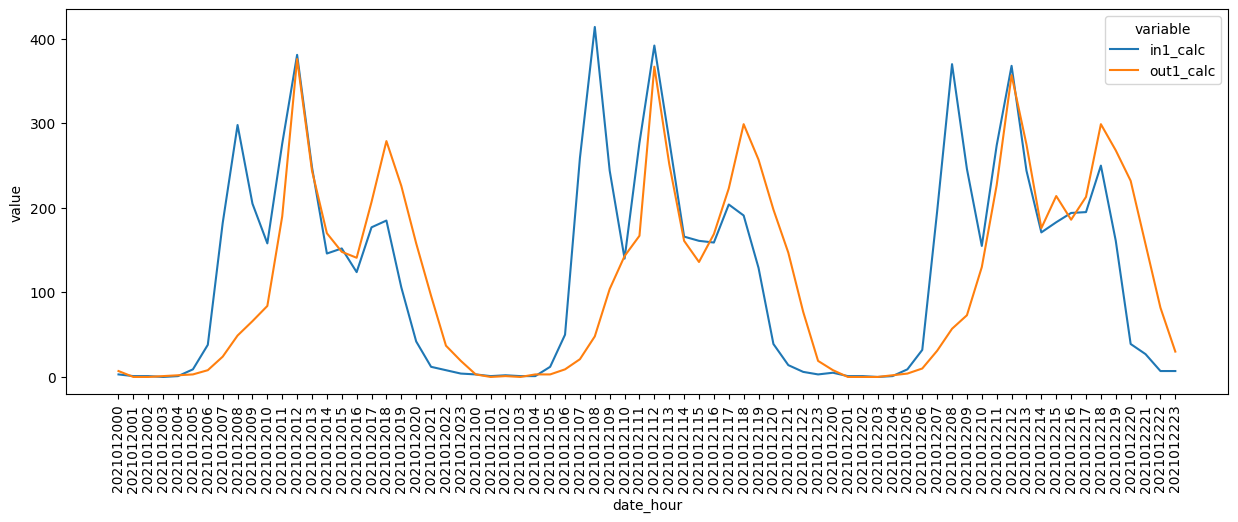

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 5))
plt.xticks(rotation=90)
sns.lineplot(x=viz_data['date_hour'], y=viz_data["value"], hue=viz_data['variable'])

このデータを見ると、8時台、12時台、18時台に山が見られます。8時台は、in1 がほとんどで、12時台、18時台はどちらも山になっています。18時台は out1_calc の方が多いですね。これは、出社時、昼休憩、退社に関係している値だと想像できます。出社時は in1 が多く、オフィス方向への移動ではないかと思います。

今回は、土日は省いていますが、土日データを可視化してみると面白いかと思います。

## ノック５０：移動平均を計算して可視化しよう
最後に、時系列データの分析方法の王道ともいえる移動平均を算出してみましょう。少し前ですが、コロナ等の報道で、7日間移動平均という言葉を耳にしたことはないでしょうか。月曜日の検査数が少なくなるなどの曜日による影響を極力減らし、感染者数が増えているのか、減っているのかをつかみたい場合には有効です。今回のデータではあまり必要ないですが、時系列データを扱う上では基本的なテクニックですのでれんしゅうしておきましょう。

まず、データを絞り込み、時単位で集計します。

In [31]:
viz_data = data_analytics[['date_hour','in1_calc','out1_calc']].groupby('date_hour',as_index=False).sum()
viz_data.head(10)

,date_hour,in1_calc,out1_calc
0,2021012000,3.0,7.0
1,2021012001,1.0,0.0
2,2021012002,1.0,0.0
3,2021012003,0.0,1.0
4,2021012004,1.0,2.0
5,2021012005,9.0,3.0
6,2021012006,38.0,8.0
7,2021012007,182.0,24.0
8,2021012008,298.0,49.0
9,2021012009,205.0,66.0


カラムを date_hour 、in1、out1 に絞り込みつつ、groupby で集計しています。

続いて、このデータフレームを用いて移動平均データを作成してみます。今回は3時間移動平均を出してみます。

In [32]:
viz_data_rolling = viz_data[['in1_calc','out1_calc']].rolling(3).mean()
viz_data_rolling.head(10)

,in1_calc,out1_calc
0,NaN,NaN
1,NaN,NaN
2,1.666667,2.333333
3,0.666667,0.333333
4,0.666667,1.000000
5,3.333333,2.000000
6,16.000000,4.333333
7,76.333333,11.666667
8,172.666667,27.000000
9,228.333333,46.333333


非常に簡単ですね。pandas には rolling という移動平均を計算する便利なメソッドが用意されているのです。データを見ると、0行目、1行目は NaN です。これは3時間移動平均を計算するためのデータがないからです。in1_calc は 1.66666667 となっていますがこれはどこからきているでしょうか。これは、viz_data の in1_calc の0行目、1行目、2行目の平均ですね。 (3+1+1+)/3=1.6666667 です。rolling にはいろいろな引数があり、平均をとるデータの範囲はもちろんのこと、3つのデータの取り方などいろいろ指定できます。.mean() の代わりに .sum() で移動合計を計算することもできます。

最後に、縦持ちデータに変換して可視化してみましょう。

<Axes: xlabel='date_hour', ylabel='value'>

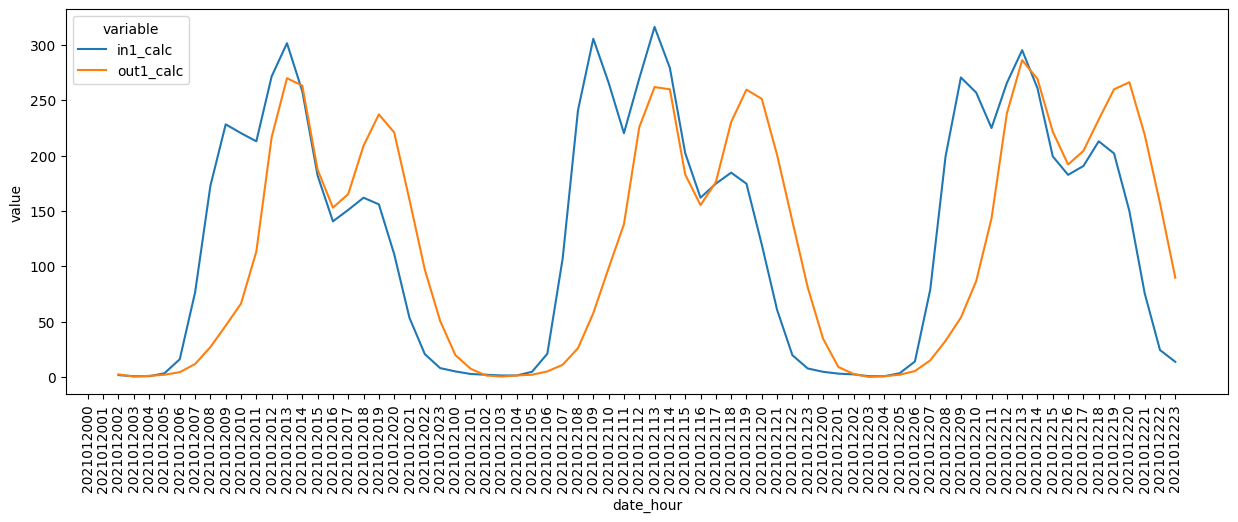

In [33]:
viz_data_rolling['date_hour'] = viz_data['date_hour']
viz_data_rolling = pd.melt(viz_data_rolling, id_vars='date_hour', value_vars=['in1_calc', 'out1_calc'])

plt.figure(figsize=(15, 5))
plt.xticks(rotation=90)
sns.lineplot(x=viz_data_rolling['date_hour'], y=viz_data_rolling["value"], hue=viz_data_rolling['variable'])

rolling データでは、date_hour 列を落としていましたので、まず、追加します。その後に、melt で縦持ちに変換して、グラフプロットしています。

ノック49のグラフに比べると、折れ線グラフの動きが穏やかになっていることが確認できます。一般的に、平均をとる幅を大きくすると動きが穏やかになってきて、よりマクロな情報になってきます。一方で、幅が大きすぎると、細かい動きは見えません。分析要件や見たいものに合わせて変えていくといいでしょう。

